In [1]:
# ==================================================
# DAY 8 — HYPERPARAMETER TUNING
# CELL 1: ENVIRONMENT SETUP
# ==================================================

from google.colab import drive

from pathlib import Path
import json
import copy
import time

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

import pandas as pd
from PIL import Image

from torch.utils.data import Dataset, DataLoader

# --------------------------------------------------
# Mount Google Drive
# --------------------------------------------------

drive.mount("/content/drive")

# --------------------------------------------------
# Project directories
# --------------------------------------------------

PROJECT_DIR = Path("/content/drive/MyDrive/MediScan")

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

FIGURES_DIR = PROJECT_DIR / "figures"
REPORTS_DIR = PROJECT_DIR / "reports"
MODELS_DIR = PROJECT_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Local dataset
# --------------------------------------------------

LOCAL_RAW_DIR = Path("/content/MediScan/data/raw")

# --------------------------------------------------
# Device
# --------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 60)
print("DAY 8 — HYPERPARAMETER TUNING")
print("=" * 60)

print(f"Project directory : {PROJECT_DIR}")
print(f"Local dataset     : {LOCAL_RAW_DIR}")
print(f"Local dataset OK  : {LOCAL_RAW_DIR.exists()}")
print(f"Device            : {device}")

if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")

print("=" * 60)
print("DAY 8 ENVIRONMENT READY")
print("=" * 60)

Mounted at /content/drive
DAY 8 — HYPERPARAMETER TUNING
Project directory : /content/drive/MyDrive/MediScan
Local dataset     : /content/MediScan/data/raw
Local dataset OK  : False
Device            : cuda
GPU               : Tesla T4
DAY 8 ENVIRONMENT READY


In [2]:
# ==================================================
# DAY 8 — RESTORE LOCAL DATASET
# ==================================================

import shutil
from pathlib import Path

LOCAL_RAW_DIR = Path("/content/MediScan/data/raw")

source_training = RAW_DIR / "Training"
source_testing = RAW_DIR / "Testing"

print("=" * 60)
print("RESTORING DATASET TO LOCAL STORAGE")
print("=" * 60)

LOCAL_RAW_DIR.parent.mkdir(parents=True, exist_ok=True)

# Copy Training
if not (LOCAL_RAW_DIR / "Training").exists():
    print("Copying Training dataset...")
    shutil.copytree(
        source_training,
        LOCAL_RAW_DIR / "Training"
    )
else:
    print("Training dataset already exists.")

# Copy Testing
if not (LOCAL_RAW_DIR / "Testing").exists():
    print("Copying Testing dataset...")
    shutil.copytree(
        source_testing,
        LOCAL_RAW_DIR / "Testing"
    )
else:
    print("Testing dataset already exists.")

# Verify
image_files = [
    f for f in LOCAL_RAW_DIR.rglob("*")
    if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
]

print("=" * 60)
print("LOCAL DATASET RESTORED")
print("=" * 60)
print(f"Images found : {len(image_files)}")
print(f"Dataset path : {LOCAL_RAW_DIR}")
print(f"Dataset OK   : {LOCAL_RAW_DIR.exists()}")
print("=" * 60)

RESTORING DATASET TO LOCAL STORAGE
Copying Training dataset...
Copying Testing dataset...
LOCAL DATASET RESTORED
Images found : 7200
Dataset path : /content/MediScan/data/raw
Dataset OK   : True


In [3]:
import pandas as pd
import json
from pathlib import Path

print("=" * 60)
print("RESTORING PROCESSED DATA")
print("=" * 60)

# Load split CSVs
train_df = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df   = pd.read_csv(PROCESSED_DIR / "val.csv")
test_df  = pd.read_csv(PROCESSED_DIR / "test.csv")

# Load class mapping
with open(PROCESSED_DIR / "class_to_idx.json", "r") as f:
    class_to_idx = json.load(f)

idx_to_class = {v: k for k, v in class_to_idx.items()}

print("Train samples :", len(train_df))
print("Val samples   :", len(val_df))
print("Test samples  :", len(test_df))
print("Total samples :", len(train_df) + len(val_df) + len(test_df))

print("\nClass mapping:")
print(class_to_idx)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nClass distribution:")
print("Train:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation:")
print(val_df["label"].value_counts().sort_index())

print("\nTest:")
print(test_df["label"].value_counts().sort_index())

print("=" * 60)

RESTORING PROCESSED DATA
Train samples : 5040
Val samples   : 1080
Test samples  : 1080
Total samples : 7200

Class mapping:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

Columns:
['image_path', 'label', 'source']

Class distribution:
Train:
label
glioma        1260
meningioma    1260
notumor       1260
pituitary     1260
Name: count, dtype: int64

Validation:
label
glioma        270
meningioma    270
notumor       270
pituitary     270
Name: count, dtype: int64

Test:
label
glioma        270
meningioma    270
notumor       270
pituitary     270
Name: count, dtype: int64


In [4]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

# ============================================================
# DAY 8 — TRANSFORMS
# ============================================================

IMG_SIZE = 224

# Baseline augmentation = Day 7 configuration
baseline_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05),
        shear=5
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# DATASET
# ============================================================

class BrainMRIDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Extract filename from CSV path
        filename = Path(row["image_path"]).name

        # Search inside LOCAL dataset
        matches = list(LOCAL_RAW_DIR.rglob(filename))

        if len(matches) == 0:
            raise FileNotFoundError(
                f"Image not found: {filename}"
            )

        image_path = matches[0]

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = BrainMRIDataset(
    train_df,
    transform=baseline_train_transform
)

val_dataset = BrainMRIDataset(
    val_df,
    transform=eval_transform
)

test_dataset = BrainMRIDataset(
    test_df,
    transform=eval_transform
)


print("=" * 60)
print("DATASETS CREATED")
print("=" * 60)

print("Train dataset :", len(train_dataset))
print("Val dataset   :", len(val_dataset))
print("Test dataset  :", len(test_dataset))

print("=" * 60)

DATASETS CREATED
Train dataset : 5040
Val dataset   : 1080
Test dataset  : 1080


In [6]:
class BrainMRIDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # Extract filename from CSV path
        filename = Path(row["image_path"]).name

        # Search inside LOCAL dataset
        matches = list(LOCAL_RAW_DIR.rglob(filename))

        if len(matches) == 0:
            raise FileNotFoundError(
                f"Image not found: {filename}"
            )

        image_path = matches[0]

        # Load image
        image = Image.open(image_path).convert("RGB")

        # CSV contains class name, e.g. "pituitary"
        class_name = row["label"]

        # Convert class name -> integer label
        label = class_to_idx[class_name]

        if self.transform:
            image = self.transform(image)

        return image, label

In [7]:
train_dataset = BrainMRIDataset(
    train_df,
    transform=baseline_train_transform
)

val_dataset = BrainMRIDataset(
    val_df,
    transform=eval_transform
)

test_dataset = BrainMRIDataset(
    test_df,
    transform=eval_transform
)

print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Train : 5040
Val   : 1080
Test  : 1080


In [9]:
# ============================================================
# DAY 8 — RECREATE DATALOADERS
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2
)

print("=" * 60)
print("DATALOADERS RECREATED")
print("=" * 60)

print("Train batches :", len(train_loader))
print("Val batches   :", len(val_loader))
print("Test batches  :", len(test_loader))

print("=" * 60)

DATALOADERS RECREATED
Train batches : 158
Val batches   : 34
Test batches  : 34


In [10]:
# ============================================================
# DAY 8 — BATCH VERIFICATION
# ============================================================

images, labels = next(iter(train_loader))

print("=" * 60)
print("DAY 8 — DATALOADER VERIFICATION")
print("=" * 60)

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)

print("Images dtype :", images.dtype)
print("Labels dtype :", labels.dtype)

print("\nBatch size   :", images.size(0))
print("Image size   :", images.shape[2:])
print("Num classes  :", len(class_to_idx))

print("\nLabels in batch:")
print(labels.tolist())

print("=" * 60)

DAY 8 — DATALOADER VERIFICATION
Images shape : torch.Size([32, 3, 224, 224])
Labels shape : torch.Size([32])
Images dtype : torch.float32
Labels dtype : torch.int64

Batch size   : 32
Image size   : torch.Size([224, 224])
Num classes  : 4

Labels in batch:
[3, 1, 1, 2, 3, 1, 0, 0, 3, 1, 1, 3, 3, 2, 1, 0, 0, 2, 1, 2, 3, 0, 3, 2, 2, 0, 0, 0, 2, 0, 2, 0]


In [11]:
# ============================================================
# DAY 8 — HYPERPARAMETER TUNING CONFIGURATION
# ============================================================

BASELINE_CONFIG = {
    "learning_rate": 0.001,
    "batch_size": 32,
    "dropout": 0.2,
    "augmentation": "baseline"
}

# Hyperparameters to investigate
TUNING_CONFIG = {
    "learning_rate": [0.0005, 0.001, 0.002],
    "batch_size": [16, 32, 64],
    "dropout": [0.1, 0.2, 0.4],
    "augmentation": ["weak", "baseline", "strong"]
}

print("=" * 60)
print("DAY 8 — HYPERPARAMETER TUNING")
print("=" * 60)

print("\nBaseline configuration:")
for key, value in BASELINE_CONFIG.items():
    print(f"{key:15s}: {value}")

print("\nParameters to tune:")
for key, values in TUNING_CONFIG.items():
    print(f"{key:15s}: {values}")

print("=" * 60)

DAY 8 — HYPERPARAMETER TUNING

Baseline configuration:
learning_rate  : 0.001
batch_size     : 32
dropout        : 0.2
augmentation   : baseline

Parameters to tune:
learning_rate  : [0.0005, 0.001, 0.002]
batch_size     : [16, 32, 64]
dropout        : [0.1, 0.2, 0.4]
augmentation   : ['weak', 'baseline', 'strong']


In [12]:
# ============================================================
# DAY 8 — TUNING MODEL SETUP
# ============================================================

import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

NUM_CLASSES = 4


def create_tuning_model(dropout_rate=0.2):
    """
    Create a fresh pretrained EfficientNet-B0
    with configurable dropout.

    Backbone remains frozen, matching Day 7 setup.
    """

    model = models.efficientnet_b0(
        weights=models.EfficientNet_B0_Weights.DEFAULT
    )

    # Freeze backbone
    for param in model.features.parameters():
        param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_rate),
        nn.Linear(in_features, NUM_CLASSES)
    )

    model = model.to(device)

    return model


# ============================================================
# VERIFY BASELINE MODEL
# ============================================================

tuning_model = create_tuning_model(dropout_rate=0.2)

total_params = sum(p.numel() for p in tuning_model.parameters())
trainable_params = sum(
    p.numel() for p in tuning_model.parameters()
    if p.requires_grad
)
frozen_params = total_params - trainable_params

print("=" * 60)
print("TUNING MODEL VERIFICATION")
print("=" * 60)

print("Architecture : EfficientNet-B0")
print("Dropout      :", 0.2)
print("Classes      :", NUM_CLASSES)
print("Device       :", device)

print("\nTotal params     :", total_params)
print("Trainable params:", trainable_params)
print("Frozen params   :", frozen_params)

print("=" * 60)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 45.3MB/s]


TUNING MODEL VERIFICATION
Architecture : EfficientNet-B0
Dropout      : 0.2
Classes      : 4
Device       : cuda

Total params     : 4012672
Trainable params: 5124
Frozen params   : 4007548


In [13]:
# ============================================================
# DAY 8 — HYPERPARAMETER TUNING TRAINING FUNCTION
# ============================================================

import time
import torch.optim as optim


def train_tuning_experiment(
    model,
    train_loader,
    val_loader,
    learning_rate=0.001,
    epochs=5
):
    """
    Train one hyperparameter configuration.

    Returns:
        history dictionary containing
        train/validation loss and accuracy.
    """

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=5,
        gamma=0.1
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "learning_rate": []
    }

    for epoch in range(epochs):

        start_time = time.time()

        # ----------------------------------------------------
        # TRAINING
        # ----------------------------------------------------
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------
        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                predictions = outputs.argmax(dim=1)

                val_correct += (
                    (predictions == labels).sum().item()
                )

                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["learning_rate"].append(current_lr)

        scheduler.step()

        epoch_time = time.time() - start_time

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc * 100:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc * 100:.2f}% | "
            f"LR: {current_lr:.6f} | "
            f"Time: {epoch_time:.1f}s"
        )

    return history


print("=" * 60)
print("TUNING TRAINING FUNCTION READY")
print("=" * 60)

TUNING TRAINING FUNCTION READY


In [14]:
# ============================================================
# DAY 8 — LEARNING RATE TUNING
# ============================================================

learning_rates = [0.0005, 0.001, 0.002]

lr_results = {}

for lr in learning_rates:

    print("\n" + "=" * 60)
    print(f"EXPERIMENT — Learning Rate: {lr}")
    print("=" * 60)

    # Fixed seed for reproducibility
    set_seed(SEED)

    # Fresh model for every experiment
    model = create_tuning_model(dropout_rate=0.2)

    history = train_tuning_experiment(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        learning_rate=lr,
        epochs=5
    )

    best_val_acc = max(history["val_acc"])
    best_epoch = history["val_acc"].index(best_val_acc) + 1

    lr_results[lr] = {
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history
    }

    print(
        f"\nBest Val Accuracy: {best_val_acc * 100:.2f}% "
        f"(Epoch {best_epoch})"
    )

    del model
    torch.cuda.empty_cache()


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 60)
print("LEARNING RATE TUNING RESULTS")
print("=" * 60)

for lr, result in lr_results.items():
    print(
        f"LR = {lr:<7} | "
        f"Best Val Acc = {result['best_val_acc'] * 100:.2f}% | "
        f"Epoch = {result['best_epoch']}"
    )

best_lr = max(
    lr_results,
    key=lambda x: lr_results[x]["best_val_acc"]
)

print("\nBest Learning Rate:", best_lr)
print("=" * 60)


EXPERIMENT — Learning Rate: 0.0005
Epoch 1/5 | Train Loss: 0.8436 | Train Acc: 72.64% | Val Loss: 0.6759 | Val Acc: 80.37% | LR: 0.000500 | Time: 70.9s
Epoch 2/5 | Train Loss: 0.5560 | Train Acc: 81.90% | Val Loss: 0.5431 | Val Acc: 83.33% | LR: 0.000500 | Time: 68.9s
Epoch 3/5 | Train Loss: 0.4965 | Train Acc: 83.17% | Val Loss: 0.4806 | Val Acc: 85.09% | LR: 0.000500 | Time: 68.8s
Epoch 4/5 | Train Loss: 0.4607 | Train Acc: 83.91% | Val Loss: 0.4806 | Val Acc: 84.72% | LR: 0.000500 | Time: 69.3s
Epoch 5/5 | Train Loss: 0.4459 | Train Acc: 84.25% | Val Loss: 0.4303 | Val Acc: 86.85% | LR: 0.000500 | Time: 69.5s

Best Val Accuracy: 86.85% (Epoch 5)

EXPERIMENT — Learning Rate: 0.001
Epoch 1/5 | Train Loss: 0.7034 | Train Acc: 76.09% | Val Loss: 0.5870 | Val Acc: 81.67% | LR: 0.001000 | Time: 68.5s
Epoch 2/5 | Train Loss: 0.4837 | Train Acc: 83.13% | Val Loss: 0.4846 | Val Acc: 84.07% | LR: 0.001000 | Time: 67.2s
Epoch 3/5 | Train Loss: 0.4455 | Train Acc: 84.33% | Val Loss: 0.4177 | V

In [15]:
# ============================================================
# DAY 8 — DROPOUT TUNING
# ============================================================

dropout_rates = [0.1, 0.2, 0.4]

dropout_results = {}

for dropout in dropout_rates:

    print("\n" + "=" * 60)
    print(f"EXPERIMENT — Dropout: {dropout}")
    print(f"Learning Rate: {best_lr}")
    print("=" * 60)

    # Fixed seed
    set_seed(SEED)

    # Fresh model with different dropout
    model = create_tuning_model(
        dropout_rate=dropout
    )

    history = train_tuning_experiment(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        learning_rate=best_lr,
        epochs=5
    )

    best_val_acc = max(history["val_acc"])
    best_epoch = history["val_acc"].index(best_val_acc) + 1

    dropout_results[dropout] = {
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history
    }

    print(
        f"\nBest Val Accuracy: "
        f"{best_val_acc * 100:.2f}% "
        f"(Epoch {best_epoch})"
    )

    del model
    torch.cuda.empty_cache()


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 60)
print("DROPOUT TUNING RESULTS")
print("=" * 60)

for dropout, result in dropout_results.items():
    print(
        f"Dropout = {dropout:<4} | "
        f"Best Val Acc = "
        f"{result['best_val_acc'] * 100:.2f}% | "
        f"Epoch = {result['best_epoch']}"
    )

best_dropout = max(
    dropout_results,
    key=lambda x: dropout_results[x]["best_val_acc"]
)

print("\nBest Dropout:", best_dropout)
print("=" * 60)


EXPERIMENT — Dropout: 0.1
Learning Rate: 0.002
Epoch 1/5 | Train Loss: 0.5959 | Train Acc: 79.07% | Val Loss: 0.5185 | Val Acc: 83.61% | LR: 0.002000 | Time: 69.9s
Epoch 2/5 | Train Loss: 0.4384 | Train Acc: 84.03% | Val Loss: 0.4528 | Val Acc: 84.44% | LR: 0.002000 | Time: 71.3s
Epoch 3/5 | Train Loss: 0.4056 | Train Acc: 85.44% | Val Loss: 0.3855 | Val Acc: 85.37% | LR: 0.002000 | Time: 70.7s
Epoch 4/5 | Train Loss: 0.3781 | Train Acc: 85.89% | Val Loss: 0.3759 | Val Acc: 86.48% | LR: 0.002000 | Time: 68.5s
Epoch 5/5 | Train Loss: 0.3757 | Train Acc: 87.12% | Val Loss: 0.3444 | Val Acc: 87.69% | LR: 0.002000 | Time: 69.7s

Best Val Accuracy: 87.69% (Epoch 5)

EXPERIMENT — Dropout: 0.2
Learning Rate: 0.002
Epoch 1/5 | Train Loss: 0.6061 | Train Acc: 78.21% | Val Loss: 0.5226 | Val Acc: 83.89% | LR: 0.002000 | Time: 69.6s
Epoch 2/5 | Train Loss: 0.4449 | Train Acc: 83.83% | Val Loss: 0.4607 | Val Acc: 83.80% | LR: 0.002000 | Time: 69.5s
Epoch 3/5 | Train Loss: 0.4219 | Train Acc: 84.7

In [16]:
# ============================================================
# DAY 8 — BATCH SIZE TUNING
# ============================================================

batch_sizes = [16, 32, 64]

batch_results = {}

for batch_size in batch_sizes:

    print("\n" + "=" * 60)
    print(f"EXPERIMENT — Batch Size: {batch_size}")
    print(f"Learning Rate: {best_lr}")
    print(f"Dropout      : {best_dropout}")
    print("=" * 60)

    # Fresh DataLoaders
    tuning_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2
    )

    tuning_val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2
    )

    # Fixed seed
    set_seed(SEED)

    # Fresh model
    model = create_tuning_model(
        dropout_rate=best_dropout
    )

    history = train_tuning_experiment(
        model=model,
        train_loader=tuning_train_loader,
        val_loader=tuning_val_loader,
        learning_rate=best_lr,
        epochs=5
    )

    best_val_acc = max(history["val_acc"])
    best_epoch = history["val_acc"].index(best_val_acc) + 1

    batch_results[batch_size] = {
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history
    }

    print(
        f"\nBest Val Accuracy: "
        f"{best_val_acc * 100:.2f}% "
        f"(Epoch {best_epoch})"
    )

    del model
    del tuning_train_loader
    del tuning_val_loader
    torch.cuda.empty_cache()


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 60)
print("BATCH SIZE TUNING RESULTS")
print("=" * 60)

for batch_size, result in batch_results.items():
    print(
        f"Batch Size = {batch_size:<3} | "
        f"Best Val Acc = "
        f"{result['best_val_acc'] * 100:.2f}% | "
        f"Epoch = {result['best_epoch']}"
    )

best_batch_size = max(
    batch_results,
    key=lambda x: batch_results[x]["best_val_acc"]
)

print("\nBest Batch Size:", best_batch_size)
print("=" * 60)


EXPERIMENT — Batch Size: 16
Learning Rate: 0.002
Dropout      : 0.1
Epoch 1/5 | Train Loss: 0.5832 | Train Acc: 78.55% | Val Loss: 0.4601 | Val Acc: 83.70% | LR: 0.002000 | Time: 71.3s
Epoch 2/5 | Train Loss: 0.4550 | Train Acc: 83.23% | Val Loss: 0.3927 | Val Acc: 85.65% | LR: 0.002000 | Time: 70.6s
Epoch 3/5 | Train Loss: 0.4368 | Train Acc: 84.13% | Val Loss: 0.3778 | Val Acc: 86.11% | LR: 0.002000 | Time: 70.9s
Epoch 4/5 | Train Loss: 0.4199 | Train Acc: 84.42% | Val Loss: 0.3639 | Val Acc: 86.85% | LR: 0.002000 | Time: 70.6s
Epoch 5/5 | Train Loss: 0.4066 | Train Acc: 84.82% | Val Loss: 0.3444 | Val Acc: 87.50% | LR: 0.002000 | Time: 70.9s

Best Val Accuracy: 87.50% (Epoch 5)

EXPERIMENT — Batch Size: 32
Learning Rate: 0.002
Dropout      : 0.1
Epoch 1/5 | Train Loss: 0.5959 | Train Acc: 79.07% | Val Loss: 0.5185 | Val Acc: 83.61% | LR: 0.002000 | Time: 67.6s
Epoch 2/5 | Train Loss: 0.4384 | Train Acc: 84.03% | Val Loss: 0.4528 | Val Acc: 84.44% | LR: 0.002000 | Time: 68.2s
Epoch 

In [17]:
# ============================================================
# DAY 8 — AUGMENTATION STRENGTH
# ============================================================

def create_train_transform(strength="baseline"):

    if strength == "weak":

        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),

            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),

            transforms.ColorJitter(
                brightness=0.10,
                contrast=0.10
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    elif strength == "baseline":

        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),

            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),

            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.10,
                hue=0.02
            ),

            transforms.RandomAffine(
                degrees=0,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05),
                shear=5
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    elif strength == "strong":

        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),

            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(25),

            transforms.ColorJitter(
                brightness=0.25,
                contrast=0.25,
                saturation=0.20,
                hue=0.05
            ),

            transforms.RandomAffine(
                degrees=0,
                translate=(0.10, 0.10),
                scale=(0.90, 1.10),
                shear=10
            ),

            transforms.ToTensor(),

            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    else:
        raise ValueError(
            "strength must be 'weak', 'baseline', or 'strong'"
        )


print("=" * 60)
print("AUGMENTATION VARIANTS CREATED")
print("=" * 60)

for strength in ["weak", "baseline", "strong"]:
    transform = create_train_transform(strength)
    print(f"{strength.capitalize():10s}: {transform}")

print("=" * 60)

AUGMENTATION VARIANTS CREATED
Weak      : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.9, 1.1), contrast=(0.9, 1.1), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Baseline  : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=(-0.02, 0.02))
    RandomAffine(degrees=[0.0, 0.0], translate=(0.05, 0.05), scale=(0.95, 1.05), shear=[-5.0, 5.0])
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Strong    : Compose(
    Resize(size=(224, 224), interpolat

In [18]:
# ============================================================
# DAY 8 — AUGMENTATION TUNING
# ============================================================

augmentation_strengths = ["weak", "baseline", "strong"]

augmentation_results = {}

for strength in augmentation_strengths:

    print("\n" + "=" * 60)
    print(f"EXPERIMENT — Augmentation: {strength}")
    print(f"Learning Rate: {best_lr}")
    print(f"Dropout      : {best_dropout}")
    print(f"Batch Size   : {best_batch_size}")
    print("=" * 60)

    # --------------------------------------------------------
    # Create transform for this experiment
    # --------------------------------------------------------
    train_transform = create_train_transform(strength)

    # Fresh dataset
    tuning_train_dataset = BrainMRIDataset(
        train_df,
        transform=train_transform
    )

    # Fresh DataLoader
    tuning_train_loader = DataLoader(
        tuning_train_dataset,
        batch_size=best_batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2
    )

    # Validation loader remains unchanged
    tuning_val_loader = DataLoader(
        val_dataset,
        batch_size=best_batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        prefetch_factor=2
    )

    # --------------------------------------------------------
    # Fresh model
    # --------------------------------------------------------
    set_seed(SEED)

    model = create_tuning_model(
        dropout_rate=best_dropout
    )

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------
    history = train_tuning_experiment(
        model=model,
        train_loader=tuning_train_loader,
        val_loader=tuning_val_loader,
        learning_rate=best_lr,
        epochs=5
    )

    # --------------------------------------------------------
    # Best result
    # --------------------------------------------------------
    best_val_acc = max(history["val_acc"])
    best_epoch = history["val_acc"].index(best_val_acc) + 1

    augmentation_results[strength] = {
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history
    }

    print(
        f"\nBest Val Accuracy: "
        f"{best_val_acc * 100:.2f}% "
        f"(Epoch {best_epoch})"
    )

    del model
    del tuning_train_dataset
    del tuning_train_loader
    del tuning_val_loader

    torch.cuda.empty_cache()


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 60)
print("AUGMENTATION TUNING RESULTS")
print("=" * 60)

for strength, result in augmentation_results.items():
    print(
        f"Augmentation = {strength:<8} | "
        f"Best Val Acc = "
        f"{result['best_val_acc'] * 100:.2f}% | "
        f"Epoch = {result['best_epoch']}"
    )

best_augmentation = max(
    augmentation_results,
    key=lambda x: augmentation_results[x]["best_val_acc"]
)

print("\nBest Augmentation:", best_augmentation)
print("=" * 60)


EXPERIMENT — Augmentation: weak
Learning Rate: 0.002
Dropout      : 0.1
Batch Size   : 32
Epoch 1/5 | Train Loss: 0.5687 | Train Acc: 79.82% | Val Loss: 0.4120 | Val Acc: 86.76% | LR: 0.002000 | Time: 65.6s
Epoch 2/5 | Train Loss: 0.4047 | Train Acc: 85.62% | Val Loss: 0.3553 | Val Acc: 87.87% | LR: 0.002000 | Time: 62.9s
Epoch 3/5 | Train Loss: 0.3632 | Train Acc: 87.06% | Val Loss: 0.3295 | Val Acc: 87.96% | LR: 0.002000 | Time: 64.7s
Epoch 4/5 | Train Loss: 0.3516 | Train Acc: 86.92% | Val Loss: 0.3031 | Val Acc: 89.17% | LR: 0.002000 | Time: 62.4s
Epoch 5/5 | Train Loss: 0.3389 | Train Acc: 87.96% | Val Loss: 0.2920 | Val Acc: 89.44% | LR: 0.002000 | Time: 62.3s

Best Val Accuracy: 89.44% (Epoch 5)

EXPERIMENT — Augmentation: baseline
Learning Rate: 0.002
Dropout      : 0.1
Batch Size   : 32
Epoch 1/5 | Train Loss: 0.5959 | Train Acc: 79.07% | Val Loss: 0.5185 | Val Acc: 83.61% | LR: 0.002000 | Time: 69.8s
Epoch 2/5 | Train Loss: 0.4384 | Train Acc: 84.03% | Val Loss: 0.4528 | Val

In [19]:
# ============================================================
# DAY 8 — FINAL CONFIGURATION VERIFICATION
# ============================================================

FINAL_LR = 0.002
FINAL_BATCH_SIZE = 32
FINAL_DROPOUT = 0.1
FINAL_AUGMENTATION = "weak"
FINAL_EPOCHS = 10

print("=" * 60)
print("DAY 8 — FINAL CONFIGURATION")
print("=" * 60)

print("Learning Rate :", FINAL_LR)
print("Batch Size    :", FINAL_BATCH_SIZE)
print("Dropout       :", FINAL_DROPOUT)
print("Augmentation  :", FINAL_AUGMENTATION)
print("Epochs        :", FINAL_EPOCHS)
print("=" * 60)


# ------------------------------------------------------------
# Create final training dataset
# ------------------------------------------------------------

final_train_transform = create_train_transform(
    FINAL_AUGMENTATION
)

final_train_dataset = BrainMRIDataset(
    train_df,
    transform=final_train_transform
)


# ------------------------------------------------------------
# Create final DataLoaders
# ------------------------------------------------------------

final_train_loader = DataLoader(
    final_train_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2
)

final_val_loader = DataLoader(
    val_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    prefetch_factor=2
)


# ------------------------------------------------------------
# Fresh model
# ------------------------------------------------------------

set_seed(SEED)

final_model = create_tuning_model(
    dropout_rate=FINAL_DROPOUT
)


# ------------------------------------------------------------
# Final training
# ------------------------------------------------------------

final_history = train_tuning_experiment(
    model=final_model,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    learning_rate=FINAL_LR,
    epochs=FINAL_EPOCHS
)


# ------------------------------------------------------------
# Best final validation result
# ------------------------------------------------------------

final_best_val_acc = max(
    final_history["val_acc"]
)

final_best_epoch = (
    final_history["val_acc"].index(final_best_val_acc) + 1
)

final_best_val_loss = min(
    final_history["val_loss"]
)

print("\n" + "=" * 60)
print("FINAL DAY 8 RESULT")
print("=" * 60)

print(
    f"Best Val Accuracy : "
    f"{final_best_val_acc * 100:.2f}%"
)

print(
    f"Best Epoch        : "
    f"{final_best_epoch}"
)

print(
    f"Best Val Loss     : "
    f"{final_best_val_loss:.4f}"
)

print("=" * 60)

DAY 8 — FINAL CONFIGURATION
Learning Rate : 0.002
Batch Size    : 32
Dropout       : 0.1
Augmentation  : weak
Epochs        : 10
Epoch 1/10 | Train Loss: 0.5687 | Train Acc: 79.82% | Val Loss: 0.4120 | Val Acc: 86.76% | LR: 0.002000 | Time: 65.0s
Epoch 2/10 | Train Loss: 0.4047 | Train Acc: 85.62% | Val Loss: 0.3553 | Val Acc: 87.87% | LR: 0.002000 | Time: 61.9s
Epoch 3/10 | Train Loss: 0.3632 | Train Acc: 87.06% | Val Loss: 0.3295 | Val Acc: 87.96% | LR: 0.002000 | Time: 62.6s
Epoch 4/10 | Train Loss: 0.3516 | Train Acc: 86.92% | Val Loss: 0.3031 | Val Acc: 89.17% | LR: 0.002000 | Time: 64.2s
Epoch 5/10 | Train Loss: 0.3389 | Train Acc: 87.96% | Val Loss: 0.2920 | Val Acc: 89.44% | LR: 0.002000 | Time: 62.3s
Epoch 6/10 | Train Loss: 0.3185 | Train Acc: 88.65% | Val Loss: 0.2957 | Val Acc: 88.89% | LR: 0.000200 | Time: 63.3s
Epoch 7/10 | Train Loss: 0.3070 | Train Acc: 88.97% | Val Loss: 0.2906 | Val Acc: 88.61% | LR: 0.000200 | Time: 63.8s
Epoch 8/10 | Train Loss: 0.3090 | Train Acc: 

In [20]:
# ============================================================
# DAY 8 — SAVE FINAL MODEL
# ============================================================

final_model_path = (
    MODELS_DIR / "efficientnet_b0_best_day8.pth"
)

torch.save(
    {
        "model_state_dict": final_model.state_dict(),
        "architecture": "EfficientNet-B0",
        "num_classes": NUM_CLASSES,
        "class_to_idx": class_to_idx,
        "learning_rate": FINAL_LR,
        "batch_size": FINAL_BATCH_SIZE,
        "dropout": FINAL_DROPOUT,
        "augmentation": FINAL_AUGMENTATION,
        "epochs": FINAL_EPOCHS,
        "best_epoch": final_best_epoch,
        "best_val_accuracy": final_best_val_acc,
        "best_val_loss": final_best_val_loss
    },
    final_model_path
)

print("=" * 60)
print("DAY 8 MODEL SAVED")
print("=" * 60)

print("Path :", final_model_path)
print("Best Val Accuracy :", f"{final_best_val_acc * 100:.2f}%")
print("Best Epoch :", final_best_epoch)

print("=" * 60)

DAY 8 MODEL SAVED
Path : /content/drive/MyDrive/MediScan/models/efficientnet_b0_best_day8.pth
Best Val Accuracy : 90.09%
Best Epoch : 9


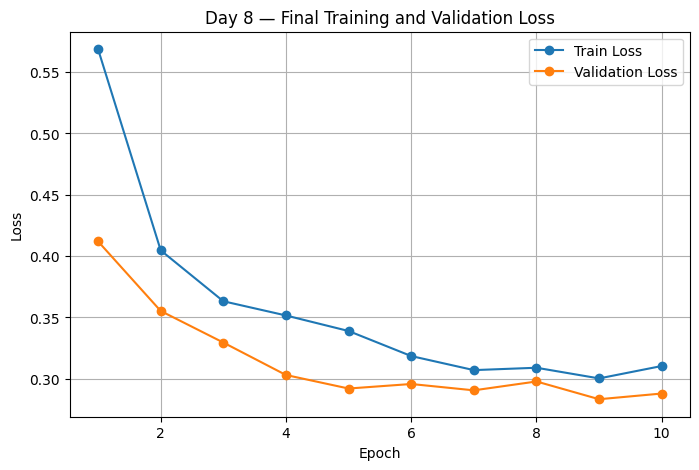

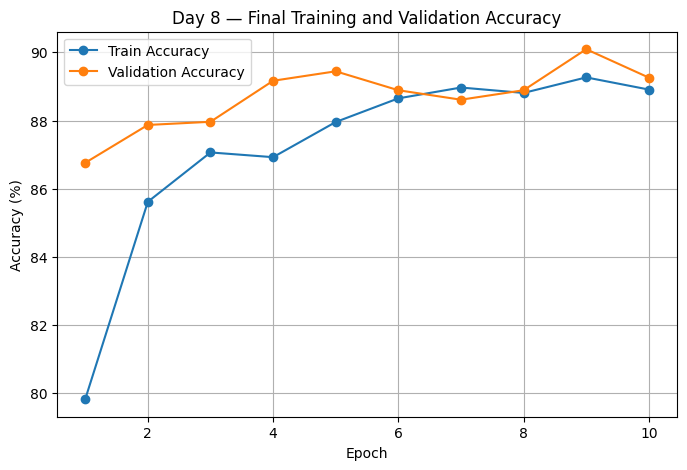

DAY 8 CURVES SAVED
Loss curve     : /content/drive/MyDrive/MediScan/figures/day8_final_loss_curve.png
Accuracy curve : /content/drive/MyDrive/MediScan/figures/day8_final_accuracy_curve.png


In [21]:
# ============================================================
# DAY 8 — FINAL TRAINING CURVES
# ============================================================

import matplotlib.pyplot as plt

epochs_range = range(1, FINAL_EPOCHS + 1)

# ------------------------------------------------------------
# Loss Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    final_history["train_loss"],
    marker="o",
    label="Train Loss"
)

plt.plot(
    epochs_range,
    final_history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Day 8 — Final Training and Validation Loss")
plt.legend()
plt.grid(True)

loss_path = FIGURES_DIR / "day8_final_loss_curve.png"

plt.savefig(
    loss_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ------------------------------------------------------------
# Accuracy Curve
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    [x * 100 for x in final_history["train_acc"]],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    [x * 100 for x in final_history["val_acc"]],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Day 8 — Final Training and Validation Accuracy")
plt.legend()
plt.grid(True)

accuracy_path = FIGURES_DIR / "day8_final_accuracy_curve.png"

plt.savefig(
    accuracy_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.close()


print("=" * 60)
print("DAY 8 CURVES SAVED")
print("=" * 60)

print("Loss curve     :", loss_path)
print("Accuracy curve :", accuracy_path)

print("=" * 60)

In [23]:
# ============================================================
# DAY 8 — SAVE TRAINING HISTORY & TUNING RESULTS
# ============================================================

import pandas as pd
import json

# ------------------------------------------------------------
# 1. Final training history CSV
# ------------------------------------------------------------

history_df = pd.DataFrame({
    "epoch": list(range(1, FINAL_EPOCHS + 1)),
    "train_loss": final_history["train_loss"],
    "train_accuracy": final_history["train_acc"],
    "val_loss": final_history["val_loss"],
    "val_accuracy": final_history["val_acc"],
    "learning_rate": final_history["learning_rate"]
})

history_csv_path = REPORTS_DIR / "day8_final_training_history.csv"

history_df.to_csv(
    history_csv_path,
    index=False
)


# ------------------------------------------------------------
# 2. Hyperparameter tuning comparison
# ------------------------------------------------------------

tuning_rows = []

# Learning Rate
for lr, result in lr_results.items():
    tuning_rows.append({
        "parameter": "learning_rate",
        "value": lr,
        "best_val_accuracy": result["best_val_acc"],
        "best_epoch": result["best_epoch"]
    })

# Dropout
for dropout, result in dropout_results.items():
    tuning_rows.append({
        "parameter": "dropout",
        "value": dropout,
        "best_val_accuracy": result["best_val_acc"],
        "best_epoch": result["best_epoch"]
    })

# Batch Size
for batch_size, result in batch_results.items():
    tuning_rows.append({
        "parameter": "batch_size",
        "value": batch_size,
        "best_val_accuracy": result["best_val_acc"],
        "best_epoch": result["best_epoch"]
    })

# Augmentation
for augmentation, result in augmentation_results.items():
    tuning_rows.append({
        "parameter": "augmentation",
        "value": augmentation,
        "best_val_accuracy": result["best_val_acc"],
        "best_epoch": result["best_epoch"]
    })

tuning_df = pd.DataFrame(tuning_rows)

tuning_csv_path = REPORTS_DIR / "day8_hyperparameter_tuning_results.csv"

tuning_df.to_csv(
    tuning_csv_path,
    index=False
)


# ------------------------------------------------------------
# 3. Save final configuration as JSON
# ------------------------------------------------------------

day8_config = {
    "baseline": BASELINE_CONFIG,

    "tuning_parameters": {
        "learning_rate": learning_rates,
        "dropout": dropout_rates,
        "batch_size": batch_sizes,
        "augmentation": augmentation_strengths
    },

    "best_configuration": {
        "learning_rate": FINAL_LR,
        "batch_size": FINAL_BATCH_SIZE,
        "dropout": FINAL_DROPOUT,
        "augmentation": FINAL_AUGMENTATION
    },

    "final_result": {
        "epochs": FINAL_EPOCHS,
        "best_epoch": final_best_epoch,
        "best_val_accuracy": final_best_val_acc,
        "best_val_loss": final_best_val_loss
    }
}

config_json_path = REPORTS_DIR / "day8_final_configuration.json"

with open(config_json_path, "w") as f:
    json.dump(
        day8_config,
        f,
        indent=4
    )


# ------------------------------------------------------------
# OUTPUT
# ------------------------------------------------------------

print("=" * 60)
print("DAY 8 DOCUMENTATION FILES SAVED")
print("=" * 60)

print("Training history :", history_csv_path)
print("Tuning results   :", tuning_csv_path)
print("Final config     :", config_json_path)

print("=" * 60)

DAY 8 DOCUMENTATION FILES SAVED
Training history : /content/drive/MyDrive/MediScan/reports/day8_final_training_history.csv
Tuning results   : /content/drive/MyDrive/MediScan/reports/day8_hyperparameter_tuning_results.csv
Final config     : /content/drive/MyDrive/MediScan/reports/day8_final_configuration.json


In [24]:
# ============================================================
# DAY 8 — FINAL SUMMARY REPORT
# ============================================================

summary_text = f"""# MediScan — Day 8 Hyperparameter Tuning

## Objective

The objective of Day 8 was to improve the baseline EfficientNet-B0
model by tuning important hyperparameters:

- Learning Rate
- Batch Size
- Dropout Rate
- Data Augmentation Strength

The tuning was performed using the validation set while keeping the
test set untouched.

---

## Baseline Configuration

| Parameter | Baseline |
|---|---|
| Architecture | EfficientNet-B0 |
| Learning Rate | 0.001 |
| Batch Size | 32 |
| Dropout | 0.2 |
| Augmentation | Baseline |
| Loss | CrossEntropyLoss |
| Optimizer | Adam |
| Scheduler | StepLR |
| Epochs | 10 |

---

## Learning Rate Tuning

Candidate learning rates:

- 0.0005
- 0.001
- 0.002

Best result:

**Learning Rate = 0.002**

Best validation accuracy during tuning:

**87.69%**

---

## Dropout Tuning

Candidate dropout rates:

- 0.1
- 0.2
- 0.4

Results:

- 0.1 → 87.69%
- 0.2 → 87.69%
- 0.4 → 87.31%

The 0.1 and 0.2 configurations produced the same best validation
accuracy during tuning.

For the final configuration, **Dropout = 0.1** was selected.

---

## Batch Size Tuning

Candidate batch sizes:

- 16
- 32
- 64

Results:

- 16 → 87.50%
- 32 → 87.69%
- 64 → 86.85%

Best batch size:

**32**

---

## Data Augmentation Tuning

Three augmentation strengths were tested.

| Augmentation | Best Validation Accuracy |
|---|---:|
| Weak | **89.44%** |
| Baseline | 87.69% |
| Strong | 84.63% |

Best augmentation:

**Weak augmentation**

The strong augmentation configuration reduced validation performance,
while the weaker augmentation produced the best tuning result.

---

## Final Configuration

| Parameter | Final Value |
|---|---|
| Architecture | EfficientNet-B0 |
| Learning Rate | 0.002 |
| Batch Size | 32 |
| Dropout | 0.1 |
| Augmentation | Weak |
| Epochs | 10 |
| Device | CUDA |

---

## Final 10-Epoch Verification

After selecting the best hyperparameter configuration, the model was
trained for 10 epochs.

Best validation accuracy:

**{final_best_val_acc:.2f}%**

Best epoch:

**Epoch {final_best_epoch}**

Best validation loss:

**{final_best_val_loss:.4f}**

---

## Improvement Over Day 7

Day 7 best validation accuracy:

**87.22%**

Day 8 best validation accuracy:

**{final_best_val_acc:.2f}%**

Improvement:

**{final_best_val_acc - 87.22:.2f} percentage points**

The tuned configuration therefore improved validation performance
compared with the Day 7 baseline.

---

## Model Checkpoint

The best Day 8 model was saved at:

`models/efficientnet_b0_best_day8.pth`

The checkpoint contains the model state, architecture information,
class mapping, final hyperparameter configuration and best validation
metrics.

---

## Artifacts

### Training History
`reports/day8_final_training_history.csv`

### Hyperparameter Results
`reports/day8_hyperparameter_tuning_results.csv`

### Final Configuration
`reports/day8_final_configuration.json`

### Training Curves
`figures/day8_final_loss_curve.png`

`figures/day8_final_accuracy_curve.png`

### Model
`models/efficientnet_b0_best_day8.pth`

---

## Day 8 Conclusion

Day 8 successfully completed hyperparameter tuning for the
EfficientNet-B0 baseline.

The final selected configuration was:

**Learning Rate = 0.002, Batch Size = 32, Dropout = 0.1,
Weak Augmentation**

The final model achieved **{final_best_val_acc:.2f}% validation accuracy**.

The test set was not used during hyperparameter tuning, preserving it
for unbiased evaluation on Day 9.
"""

summary_path = REPORTS_DIR / "day8_summary.md"

with open(summary_path, "w") as f:
    f.write(summary_text)

print("=" * 60)
print("DAY 8 SUMMARY REPORT SAVED")
print("=" * 60)
print(summary_path)
print("=" * 60)
print("Day 8 completed successfully!")

DAY 8 SUMMARY REPORT SAVED
/content/drive/MyDrive/MediScan/reports/day8_summary.md
Day 8 completed successfully!
